# E38 — Mais fundo, mais junto

O par real medido em cinco profundidades de corte, e a TAXA com que a junta cai --- o expoente lido
direto do dado, com intervalo por bootstrap de blocos, contra a gaussiana e a t com a MESMA
correlação de posto, na mesma janela e com o mesmo estimador. Critérios na docstring do construtor.

In [1]:
import sys
sys.path.insert(0, "lib")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats as st
from scipy.special import gammaln

from frevolab import dados, graficos, profundidade

SEMENTE = 105          # <- brinque com:
CORTES = (0.05, 0.02, 0.01, 0.005, 0.0025)
NOMES = {0.05: "cinco", 0.02: "dois", 0.01: "um", 0.005: "meio", 0.0025: "um_quarto"}
JANELA = 252
BLOCO = 60
REPETICOES = 200
NI_GRADE = tuple(range(2, 21))

preco_sp = dados.carregar_serie("sp500.csv")
preco_ib = dados.carregar_serie("ibov.csv")
retornos_sp = preco_sp.pct_change().dropna()
retornos_ib = preco_ib.pct_change().dropna()
print("sp %d | ibov %d dias" % (retornos_sp.size, retornos_ib.size))

sp 6718 | ibov 6620 dias


In [2]:
# O par real nas cinco profundidades, e o expoente lido direto do dado.
comuns = retornos_sp.index.intersection(retornos_ib.index)
rho_posto = float(st.spearmanr(retornos_sp.loc[comuns], retornos_ib.loc[comuns]).statistic)
ESCALA_SP = float(retornos_sp.loc[comuns].std())
ESCALA_IB = float(retornos_ib.loc[comuns].std())
caixas_real = profundidade.razoes(retornos_sp, retornos_ib, cortes=CORTES, janela=JANELA)
for corte in CORTES:
    caixa = caixas_real[corte]
    print("corte %.4f | juntos %3d | esperado %.2f | razao %6.2f" % (
        corte, caixa["juntos"], caixa["juntos"] / caixa["excesso"], caixa["excesso"]))
alfa_real = profundidade.expoente(CORTES, caixas_real)
print("rho posto %.4f | n %d | alfa real %.3f" % (rho_posto, comuns.size, alfa_real))

corte 0.0500 | juntos 113 | esperado 16.01 | razao   7.06
corte 0.0200 | juntos  45 | esperado 3.97 | razao  11.34
corte 0.0100 | juntos  20 | esperado 1.00 | razao  20.07
corte 0.0050 | juntos  16 | esperado 0.52 | razao  30.76
corte 0.0025 | juntos   8 | esperado 0.12 | razao  64.56
rho posto 0.5036 | n 6450 | alfa real 1.269


In [3]:
# O intervalo do expoente: bootstrap de blocos, o desenho do capitulo do orcamento.
lo_real, hi_real = profundidade.intervalo(retornos_sp, retornos_ib, CORTES,
                                          janela=JANELA, bloco=BLOCO,
                                          repeticoes=REPETICOES, semente=SEMENTE + 300)
print("alfa real %.3f | intervalo [%.3f; %.3f]" % (alfa_real, lo_real, hi_real))

alfa real 1.269 | intervalo [1.184; 1.615]


In [4]:
# O grau de liberdade da t, por maxima verossimilhanca na grade declarada.
za = (retornos_sp.loc[comuns] - retornos_sp.loc[comuns].mean()) / ESCALA_SP
zb = (retornos_ib.loc[comuns] - retornos_ib.loc[comuns].mean()) / ESCALA_IB
rho_pearson = float(np.corrcoef(za, zb)[0, 1])
qua = (za ** 2 - 2 * rho_pearson * za * zb + zb ** 2) / (1 - rho_pearson ** 2)
logliks = {}
for ni in NI_GRADE:
    logliks[ni] = float(-len(qua) * (gammaln((ni + 2) / 2) - gammaln(ni / 2) - np.log(ni))
                        - ((ni + 2) / 2) * np.log1p(qua / ni).sum())
NI_MLE = max(logliks, key=logliks.get)
print("rho pearson %.4f | ni por MLE na grade: %d" % (rho_pearson, NI_MLE))

rho pearson 0.5890 | ni por MLE na grade: 9


In [5]:
# Os controles com a MESMA correlacao de posto, na mesma janela, com o mesmo estimador.
ga, gb = profundidade.controle_gaussiano(comuns.size, np.random.default_rng(SEMENTE + 100), rho_posto)
serie_ga = pd.Series(ESCALA_SP * ga.to_numpy(), index=comuns)
serie_gb = pd.Series(ESCALA_IB * gb.to_numpy(), index=comuns)
caixas_gauss = profundidade.razoes(serie_ga, serie_gb, cortes=CORTES, janela=JANELA)
alfa_gauss = profundidade.expoente(CORTES, caixas_gauss)

ta, tb = profundidade.controle_t(comuns.size, np.random.default_rng(SEMENTE + 200), rho_posto, NI_MLE)
serie_ta = pd.Series(ESCALA_SP * ta.to_numpy(), index=comuns)
serie_tb = pd.Series(ESCALA_IB * tb.to_numpy(), index=comuns)
caixas_t = profundidade.razoes(serie_ta, serie_tb, cortes=CORTES, janela=JANELA)
alfa_t = profundidade.expoente(CORTES, caixas_t)

lo_g, hi_g = profundidade.intervalo(serie_ga, serie_gb, CORTES, janela=JANELA, bloco=BLOCO,
                                    repeticoes=REPETICOES, semente=SEMENTE + 400)
lo_t, hi_t = profundidade.intervalo(serie_ta, serie_tb, CORTES, janela=JANELA, bloco=BLOCO,
                                    repeticoes=REPETICOES, semente=SEMENTE + 500)
print("gauss: alfa %.3f [%+.3f; %+.3f]" % (alfa_gauss, lo_g, hi_g))
print("t    : alfa %.3f [%+.3f; %+.3f]" % (alfa_t, lo_t, hi_t))

gauss: alfa 1.572 [+1.169; +1.808]
t    : alfa 1.296 [+1.114; +1.707]


In [6]:
# O controle negativo: pernas independentes com as margens do par real.
rng_ind = np.random.default_rng(SEMENTE + 600)
serie_ia = pd.Series(ESCALA_SP * rng_ind.normal(0.0, 1.0, comuns.size), index=comuns)
serie_ib = pd.Series(ESCALA_IB * rng_ind.normal(0.0, 1.0, comuns.size), index=comuns)
caixas_ind = profundidade.razoes(serie_ia, serie_ib, cortes=CORTES, janela=JANELA)
alfa_ind = profundidade.expoente(CORTES, caixas_ind)
for corte in CORTES:
    caixa = caixas_ind[corte]
    print("corte %.4f | juntos %2d | razao %.2f" % (corte, caixa["juntos"], caixa["excesso"]))
print("alfa independente %.3f (a independencia carrega o dois)" % alfa_ind)

corte 0.0500 | juntos 11 | razao 0.69
corte 0.0200 | juntos  3 | razao 0.84
corte 0.0100 | juntos  2 | razao 2.20
corte 0.0050 | juntos  1 | razao 2.62
corte 0.0025 | juntos  1 | razao 9.98
alfa independente 1.135 (a independencia carrega o dois)


In [7]:
# O preco: a conversao que nao existia entre a medida rasa e a conta funda.
ancora = caixas_real[0.05]["excesso"]
promessa_proporcional = ancora * 10.0
alfa_assintotico = 2.0 / (1.0 + 2.0 * np.sin(np.pi * rho_posto / 6.0))
promessa_gaussiana = ancora * 10.0 ** (2.0 - alfa_assintotico)
esperado_fundo = caixas_real[0.005]["juntos"] / caixas_real[0.005]["excesso"]
preco_medidos = caixas_real[0.005]["juntos"]
preco_gauss_janela = caixas_gauss[0.005]["juntos"]
preco_t_janela = caixas_t[0.005]["juntos"]
preco_assintotico = esperado_fundo * promessa_gaussiana
descoberto = 1.0 - preco_gauss_janela / preco_medidos
print("alfa assintotico da gaussiana com este posto: %.3f" % alfa_assintotico)
print("promessas do corte de 5%% para o de 0,5%%: proporcional %.1f | gaussiana assintotica %.1f" % (
    promessa_proporcional, promessa_gaussiana))
print("eventos no corte fundo: esperado %.2f | gauss janela %d | assintotico %.1f | t janela %d | medido %d" % (
    esperado_fundo, preco_gauss_janela, preco_assintotico, preco_t_janela, preco_medidos))
print("fracao descoberta da protecao gaussiana: %.4f" % descoberto)

alfa assintotico da gaussiana com este posto: 1.315
promessas do corte de 5% para o de 0,5%: proporcional 70.6 | gaussiana assintotica 34.2
eventos no corte fundo: esperado 0.52 | gauss janela 6 | assintotico 17.8 | t janela 12 | medido 16
fracao descoberta da protecao gaussiana: 0.6250


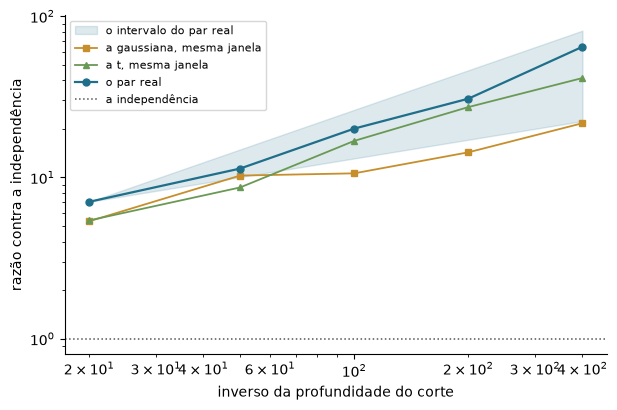

In [8]:
# Figura 1: a taxa com que cada estrutura cai, em log-log.
xs = np.array([1.0 / c for c in CORTES])
valido_g = [(1.0 / c, caixas_gauss[c]["excesso"]) for c in CORTES if caixas_gauss[c]["juntos"] > 0]
valido_t = [(1.0 / c, caixas_t[c]["excesso"]) for c in CORTES if caixas_t[c]["juntos"] > 0]
valido_r = [(1.0 / c, caixas_real[c]["excesso"]) for c in CORTES if caixas_real[c]["juntos"] > 0]
xg, yg = np.array([p for p, _ in valido_g]), np.array([r for _, r in valido_g])
xt_, yt_ = np.array([p for p, _ in valido_t]), np.array([r for _, r in valido_t])
xr, yr = np.array([p for p, _ in valido_r]), np.array([r for _, r in valido_r])
fig, ax = plt.subplots(figsize=(7.0, 4.4))
x0, y0 = xs[0], caixas_real[0.05]["excesso"]
faixa = np.linspace(xs[0], xs[-1], 50)
ax.fill_between(faixa, y0 * (faixa / x0) ** (2.0 - lo_real), y0 * (faixa / x0) ** (2.0 - hi_real),
                color="#1f6f8b", alpha=0.15, label="o intervalo do par real")
ax.plot(xg, yg, "s-", color="#c78f2c", lw=1.3, ms=4.5, label="a gaussiana, mesma janela")
ax.plot(xt_, yt_, "^-", color="#6a9955", lw=1.3, ms=4.5, label="a t, mesma janela")
ax.plot(xr, yr, "o-", color="#1f6f8b", lw=1.6, ms=5, label="o par real")
ax.axhline(1.0, color="#555555", ls=":", lw=1.1, label="a independência")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("inverso da profundidade do corte")
ax.set_ylabel("razão contra a independência")
ax.legend(fontsize=8, loc="best")
ax.spines[["top", "right"]].set_visible(False)
graficos.salvar(fig, "E38_mais_fundo", 1)
plt.show()

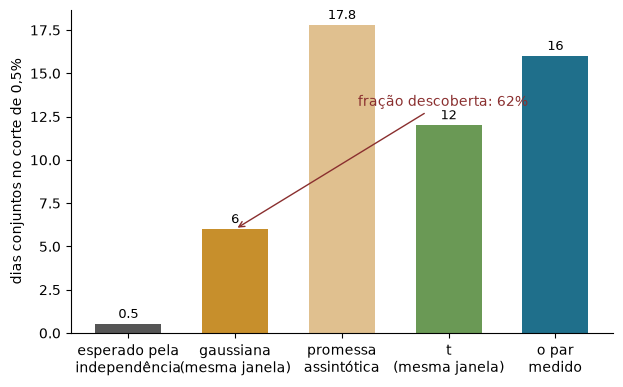

In [9]:
# Figura 2: o preco no corte fundo, evento a evento.
rotulos = ["esperado pela\nindependência", "gaussiana\n(mesma janela)", "promessa\nassintótica",
           "t\n(mesma janela)", "o par\nmedido"]
valores = [esperado_fundo, preco_gauss_janela, preco_assintotico, preco_t_janela, preco_medidos]
cores = ["#555555", "#c78f2c", "#e0c08f", "#6a9955", "#1f6f8b"]
fig, ax = plt.subplots(figsize=(7.0, 4.2))
ax.bar(rotulos, valores, color=cores, width=0.62)
for i, v in enumerate(valores):
    ax.text(i, v + 0.35, ("%.1f" % v) if isinstance(v, float) else str(v),
            ha="center", fontsize=9)
ax.annotate("fração descoberta: %.0f%%" % (100 * descoberto),
            xy=(1, preco_gauss_janela), xytext=(2.15, preco_medidos * 0.82),
            arrowprops=dict(arrowstyle="->", color="#8a2f2f"), color="#8a2f2f", fontsize=10)
ax.set_ylabel("dias conjuntos no corte de 0,5%")
ax.spines[["top", "right"]].set_visible(False)
graficos.salvar(fig, "E38_mais_fundo", 2)
plt.show()

In [10]:
# Leitura visual das figuras (declaratória, contra o PNG):
# 1) o eixo y vai de dez a zero em potências (10^0 a 10^2) e o x de vinte a quatrocentos: as curvas
#    sobem da esquerda para a direita; o par real (azul, com a faixa clara do intervalo) é a curva de
#    mais cima no fundo; a t (verde) acompanha de perto, um pouco abaixo; a gaussiana (laranja) sobe
#    menos; a independência é a linha pontilhada horizontal no valor um;
# 2) cinco barras: esperado 0,5 (quase nada), gauss janela 6, promessa assintótica 17,8 (a mais
#    alta), t janela 12, medido 16; a seta vermelha «fração descoberta: 62%» aponta da barra da
#    gaussiana para a região do medido.

In [11]:
# O que sai do laboratório e o que o livro cita.
resultado = {"fundo_dias_comuns": int(comuns.size),
             "fundo_rho_posto": round(rho_posto, 4),
             "fundo_rho_pearson": round(rho_pearson, 4),
             "fundo_ni": int(NI_MLE),
             "fundo_alfa_real": round(alfa_real, 3),
             "fundo_alfa_real_min": round(lo_real, 3),
             "fundo_alfa_real_max": round(hi_real, 3),
             "fundo_alfa_gauss": round(alfa_gauss, 3),
             "fundo_alfa_gauss_min": round(lo_g, 3),
             "fundo_alfa_gauss_max": round(hi_g, 3),
             "fundo_alfa_t": round(alfa_t, 3),
             "fundo_alfa_t_min": round(lo_t, 3),
             "fundo_alfa_t_max": round(hi_t, 3),
             "fundo_alfa_independente": round(alfa_ind, 3),
             "fundo_alfa_assintotico": round(alfa_assintotico, 3),
             "fundo_esperado_cinco": round(caixas_real[0.05]["juntos"] / caixas_real[0.05]["excesso"], 2),
             "fundo_esperado_um_quarto": round(caixas_real[0.0025]["juntos"] / caixas_real[0.0025]["excesso"], 2),
             "fundo_promessa_proporcional": round(promessa_proporcional, 1),
             "fundo_promessa_gaussiana": round(promessa_gaussiana, 1),
             "fundo_preco_esperado": round(esperado_fundo, 2),
             "fundo_preco_gauss_janela": int(preco_gauss_janela),
             "fundo_preco_assintotico": round(preco_assintotico, 1),
             "fundo_preco_t_janela": int(preco_t_janela),
             "fundo_preco_medidos": int(preco_medidos),
             "fundo_preco_descoberto": round(descoberto, 4)}
for corte in CORTES:
    caixa = caixas_real[corte]
    resultado["fundo_juntos_%s" % NOMES[corte]] = int(caixa["juntos"])
    resultado["fundo_razao_%s" % NOMES[corte]] = round(float(caixa["excesso"]), 2)

CITADAS_NO_LIVRO = tuple(sorted(resultado))
resultado = {k: v for k, v in resultado.items() if k in CITADAS_NO_LIVRO}
import json
from pathlib import Path
caminho = Path("lab/resultados/E38_mais_fundo.json")
caminho.write_text(json.dumps(resultado, indent=1, ensure_ascii=False, sort_keys=True), encoding="utf-8")
print(json.dumps(resultado, ensure_ascii=False, indent=1, sort_keys=True))

{
 "fundo_alfa_assintotico": 1.315,
 "fundo_alfa_gauss": 1.572,
 "fundo_alfa_gauss_max": 1.808,
 "fundo_alfa_gauss_min": 1.169,
 "fundo_alfa_independente": 1.135,
 "fundo_alfa_real": 1.269,
 "fundo_alfa_real_max": 1.615,
 "fundo_alfa_real_min": 1.184,
 "fundo_alfa_t": 1.296,
 "fundo_alfa_t_max": 1.707,
 "fundo_alfa_t_min": 1.114,
 "fundo_dias_comuns": 6450,
 "fundo_esperado_cinco": 16.01,
 "fundo_esperado_um_quarto": 0.12,
 "fundo_juntos_cinco": 113,
 "fundo_juntos_dois": 45,
 "fundo_juntos_meio": 16,
 "fundo_juntos_um": 20,
 "fundo_juntos_um_quarto": 8,
 "fundo_ni": 9,
 "fundo_preco_assintotico": 17.8,
 "fundo_preco_descoberto": 0.625,
 "fundo_preco_esperado": 0.52,
 "fundo_preco_gauss_janela": 6,
 "fundo_preco_medidos": 16,
 "fundo_preco_t_janela": 12,
 "fundo_promessa_gaussiana": 34.2,
 "fundo_promessa_proporcional": 70.6,
 "fundo_razao_cinco": 7.06,
 "fundo_razao_dois": 11.34,
 "fundo_razao_meio": 30.76,
 "fundo_razao_um": 20.07,
 "fundo_razao_um_quarto": 64.56,
 "fundo_rho_pearson